In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
data = pd.read_csv("../Dataset/IMDB Dataset.csv")

In [67]:
data

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [68]:
data.shape

(50000, 2)

In [69]:
data.columns

Index(['review', 'sentiment'], dtype='str')

In [70]:
data.dtypes

review       str
sentiment    str
dtype: object

In [71]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


In [72]:
data.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [73]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [74]:
data.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


In [75]:
data.iloc[0]

review       One of the other reviewers has mentioned that ...
sentiment                                             positive
Name: 0, dtype: str

In [76]:
data.iloc[0]["review"]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [77]:
data.iloc[0]["sentiment"]

'positive'

In [78]:
missing_values = data.isnull().sum()

In [79]:
missing_values

review       0
sentiment    0
dtype: int64

In [80]:
missing_values_percentage = (missing_values / len(data)) * 100

In [81]:
missing_values_percentage

review       0.0
sentiment    0.0
dtype: float64

In [82]:
duplicate_rows = data.duplicated().sum()

In [83]:
duplicate_rows

np.int64(418)

In [84]:
duplicate_rows = data[data.duplicated()]

In [85]:
duplicate_rows

,review,sentiment
3537,Quite what the producers of this appalling ada...,negative
3769,My favourite police series of all time turns t...,positive
4391,"Beautiful film, pure Cassavetes style. Gena Ro...",positive
6352,If you liked the Grinch movie... go watch that...,negative
6479,I want very much to believe that the above quo...,negative
...,...,...
49912,This is an incredible piece of drama and power...,positive
49950,This was a very brief episode that appeared in...,negative
49984,Hello it is I Derrick Cannon and I welcome you...,negative
49986,This movie is a disgrace to the Major League F...,negative


In [86]:
duplicate_reviews = data["review"].duplicated().sum()
duplicate_reviews

np.int64(418)

In [87]:
duplicate_data = duplicate_rows.iloc[0]

In [88]:
duplicate_data

review       Quite what the producers of this appalling ada...
sentiment                                             negative
Name: 3537, dtype: str

In [89]:
fetch_first_duplicate = duplicate_rows[duplicate_rows == duplicate_data]

In [90]:
fetch_first_duplicate

,review,sentiment
3537,Quite what the producers of this appalling ada...,negative
3769,NaN,NaN
4391,NaN,NaN
6352,NaN,negative
6479,NaN,negative
...,...,...
49912,NaN,NaN
49950,NaN,negative
49984,NaN,negative
49986,NaN,negative


In [91]:
fetch_first_duplicate = duplicate_rows[(duplicate_rows == duplicate_data).all(axis=1)]

In [92]:
fetch_first_duplicate

,review,sentiment
3537,Quite what the producers of this appalling ada...,negative


In [93]:
all_duplicates = data[data.duplicated(keep=False)]

In [94]:
all_duplicates

,review,sentiment
42,"Of all the films I have seen, this one, The Ra...",negative
84,"We brought this film as a joke for a friend, a...",negative
140,"Before I begin, let me get something off my ch...",negative
219,Ed Wood rides again. The fact that this movie ...,negative
245,I have seen this film at least 100 times and I...,positive
...,...,...
49912,This is an incredible piece of drama and power...,positive
49950,This was a very brief episode that appeared in...,negative
49984,Hello it is I Derrick Cannon and I welcome you...,negative
49986,This movie is a disgrace to the Major League F...,negative


In [95]:
data["sentiment"].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

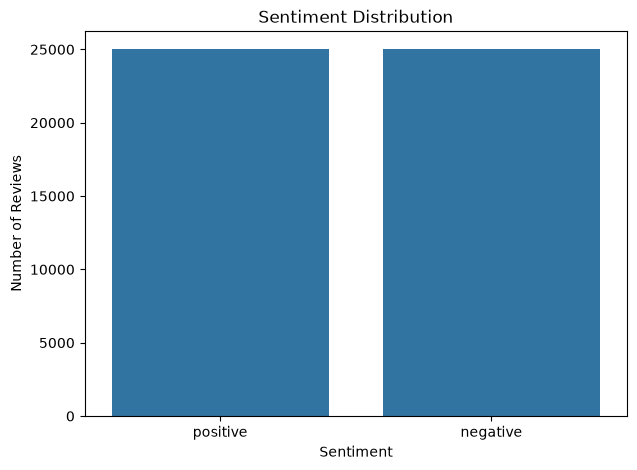

In [96]:
plt.figure(figsize=(7, 5))

sns.countplot(data=data, x="sentiment")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [97]:
data["review_length"] = data["review"].str.len()

data.head()

,review,sentiment,review_length
0,One of the other reviewers has mentioned that ...,positive,1761
1,A wonderful little production. <br /><br />The...,positive,998
2,I thought this was a wonderful way to spend ti...,positive,926
3,Basically there's a family where a little boy ...,negative,748
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317


In [98]:
data["review_length"].describe()

count    50000.000000
mean      1309.431020
std        989.728014
min         32.000000
25%        699.000000
50%        970.000000
75%       1590.250000
max      13704.000000
Name: review_length, dtype: float64

In [99]:
data["review"].str.split()

0        [One, of, the, other, reviewers, has, mentione...
1        [A, wonderful, little, production., <br, /><br...
2        [I, thought, this, was, a, wonderful, way, to,...
3        [Basically, there's, a, family, where, a, litt...
4        [Petter, Mattei's, "Love, in, the, Time, of, M...
                               ...                        
49995    [I, thought, this, movie, did, a, down, right,...
49996    [Bad, plot,, bad, dialogue,, bad, acting,, idi...
49997    [I, am, a, Catholic, taught, in, parochial, el...
49998    [I'm, going, to, have, to, disagree, with, the...
49999    [No, one, expects, the, Star, Trek, movies, to...
Name: review, Length: 50000, dtype: object

In [100]:
data["review"].str.split().str.len()

0        307
1        162
2        166
3        138
4        230
        ... 
49995    194
49996    112
49997    230
49998    212
49999    129
Name: review, Length: 50000, dtype: int64

In [101]:
data["word_count"] = data["review"].str.split().str.len()

In [102]:
data.head()

,review,sentiment,review_length,word_count
0,One of the other reviewers has mentioned that ...,positive,1761,307
1,A wonderful little production. <br /><br />The...,positive,998,162
2,I thought this was a wonderful way to spend ti...,positive,926,166
3,Basically there's a family where a little boy ...,negative,748,138
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317,230


In [103]:
print(data["word_count"].describe())

count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: word_count, dtype: float64


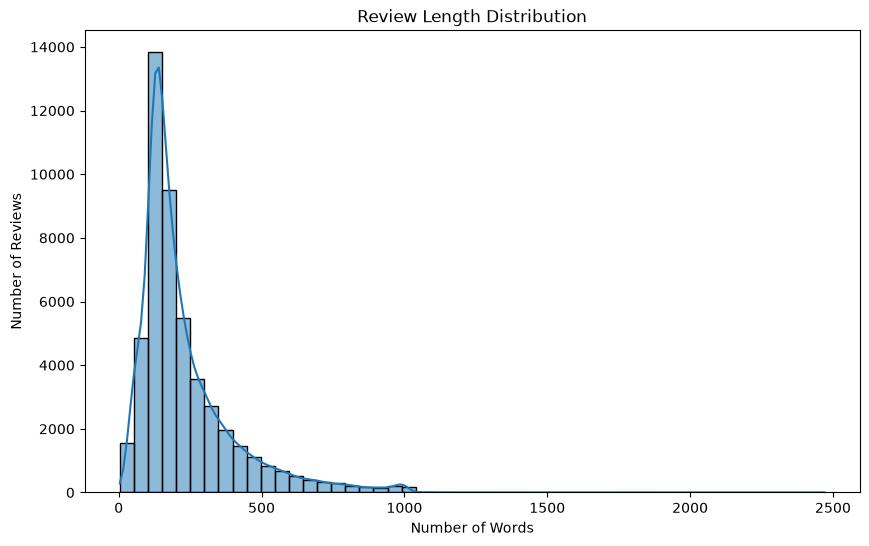

In [104]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=data,
    x="word_count",
    bins=50,
    kde=True
)

plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")

plt.show()

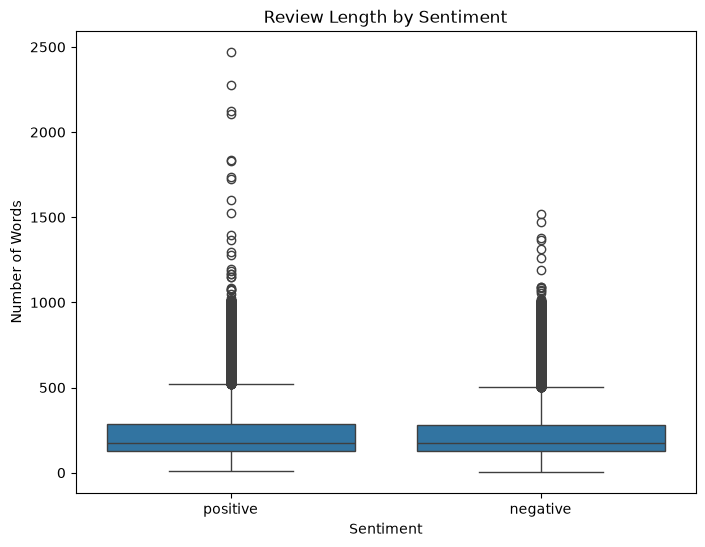

In [105]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=data,
    x="sentiment",
    y="word_count"
)

plt.title("Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Words")

plt.show()

In [106]:
from collections import Counter
import re

import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud

In [107]:
nltk.download("stopwords")

/home/aximsoft/snap/code/258/.local/share/virtualenvs/Text_Sentiment_Analysis-D79r_KZq/lib/python3.13/site-packages/nltk/downloader.py:1076: UserWarning: NLTK will not authorize the non-private download directory '/home/aximsoft/nltk_data': it (or an ancestor) is world- or group-writable, so another local user could plant files there. Choose a private location such as ~/nltk_data.
  for msg in self.incr_download(info_or_id, download_dir, force):
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/aximsoft/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [108]:
len(stopwords.words("tamil"))

125

In [109]:
st_words = stopwords.words("english")

In [110]:
st_words

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [111]:
st_words.__class__

list

In [112]:
NEGATION_WORDS = {
    "no",
    "not",
    "nor",
    "never",
    "neither",
    "none",
    "nobody",
    "nothing",
    "nowhere",
    "hardly",
    "scarcely",
    "barely",
    "isn't",
    "wasn't",
    "didn't",
    "don't",
    "can't",
    "couldn't",
    "won't"
}

In [113]:
stop_words = set(stopwords.words("english"))

print("Number of stopwords:", len(stop_words))

Number of stopwords: 198


In [114]:
stop_words = stop_words - NEGATION_WORDS

In [115]:
stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 'd',
 'did',
 'didn',
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'only',
 'or',
 'other',
 'our',
 'ours',
 'ourselves',
 'out',
 'over

In [ ]:
def clean_text_for_eda(text):
    text = text.lower()

    text = re.sub(r"<.*?>", " ", text)

    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    
    words = text.split()

    words = [
        word
        for word in words
        if word not in stop_words
    ]

    return words

In [117]:
word_counter = Counter()

for review in data["review"]:
    words = clean_text_for_eda(review)
    word_counter.update(words)

In [118]:
word_counter

Counter({'movie': 87972,
         'film': 79708,
         'not': 60750,
         'one': 53603,
         'like': 40172,
         'good': 29753,
         'no': 25301,
         'time': 25109,
         'even': 24872,
         'would': 24602,
         'story': 23121,
         'really': 23095,
         'see': 23029,
         'well': 21269,
         'much': 19320,
         'bad': 18473,
         'get': 18422,
         'people': 18188,
         'great': 18145,
         'also': 17977,
         'first': 17583,
         'made': 16152,
         'make': 15898,
         'way': 15645,
         'could': 15565,
         'movies': 15309,
         'characters': 14456,
         'think': 14338,
         'watch': 13946,
         'character': 13905,
         'films': 13755,
         'two': 13545,
         'many': 13446,
         'seen': 13376,
         'love': 13009,
         'plot': 12987,
         'never': 12981,
         'life': 12919,
         'acting': 12867,
         'show': 12656,
         'best': 126

In [119]:
most_common_words = word_counter.most_common(20)

most_common_words

[('movie', 87972),
 ('film', 79708),
 ('not', 60750),
 ('one', 53603),
 ('like', 40172),
 ('good', 29753),
 ('no', 25301),
 ('time', 25109),
 ('even', 24872),
 ('would', 24602),
 ('story', 23121),
 ('really', 23095),
 ('see', 23029),
 ('well', 21269),
 ('much', 19320),
 ('bad', 18473),
 ('get', 18422),
 ('people', 18188),
 ('great', 18145),
 ('also', 17977)]

In [120]:
word_frequency_df = pd.DataFrame(
    most_common_words,
    columns=["word", "frequency"]
)

word_frequency_df

,word,frequency
0,movie,87972
1,film,79708
2,not,60750
3,one,53603
4,like,40172
5,good,29753
6,no,25301
7,time,25109
8,even,24872
9,would,24602


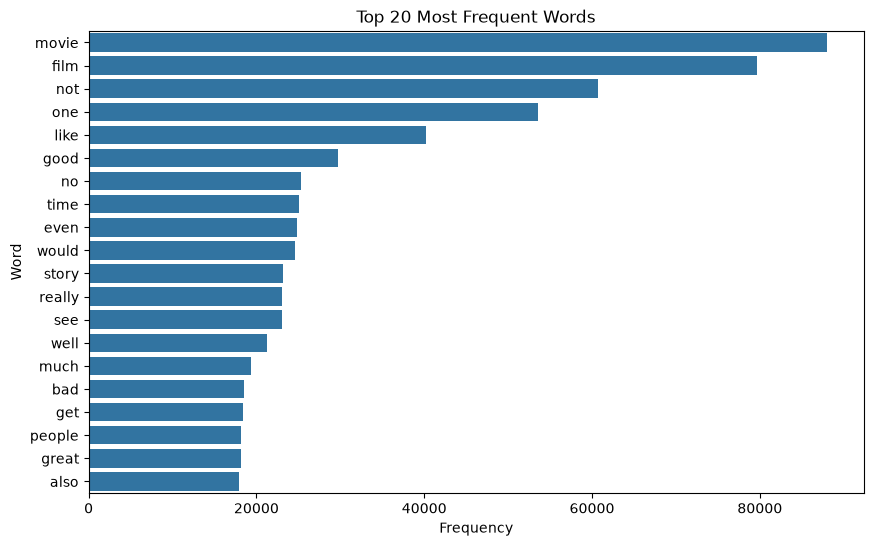

In [121]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=word_frequency_df,
    x="frequency",
    y="word"
)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

In [122]:
positive_counter = Counter()
negative_counter = Counter()

for _, row in data.iterrows():

    words = clean_text_for_eda(row["review"])

    if row["sentiment"] == "positive":
        positive_counter.update(words)

    else:
        negative_counter.update(words)

In [123]:
positive_words = pd.DataFrame(
    positive_counter.most_common(20),
    columns=["word", "frequency"]
)

positive_words

,word,frequency
0,film,42111
1,movie,37854
2,not,28303
3,one,27320
4,like,17714
5,good,15025
6,great,12964
7,story,12935
8,time,12752
9,well,12729


In [124]:
negative_words = pd.DataFrame(
    negative_counter.most_common(20),
    columns=["word", "frequency"]
)

negative_words

,word,frequency
0,movie,50118
1,film,37597
2,not,32447
3,one,26283
4,like,22458
5,no,16063
6,even,15254
7,good,14728
8,bad,14726
9,would,14007


In [125]:
# Word Cloud for Positive Reviews

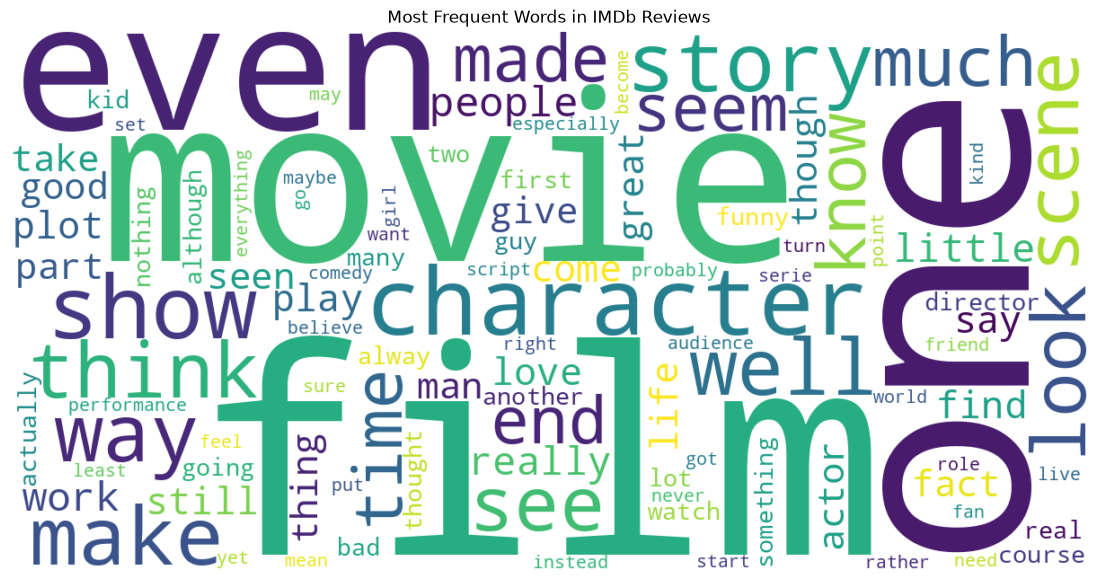

In [ ]:
all_words = " ".join( data["review"].apply( lambda text: " ".join(clean_text_for_eda(text)) ) )

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=100
).generate(all_words)

plt.figure(figsize=(14, 7))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")
plt.title("Most Frequent Words in IMDb Reviews")

plt.show()

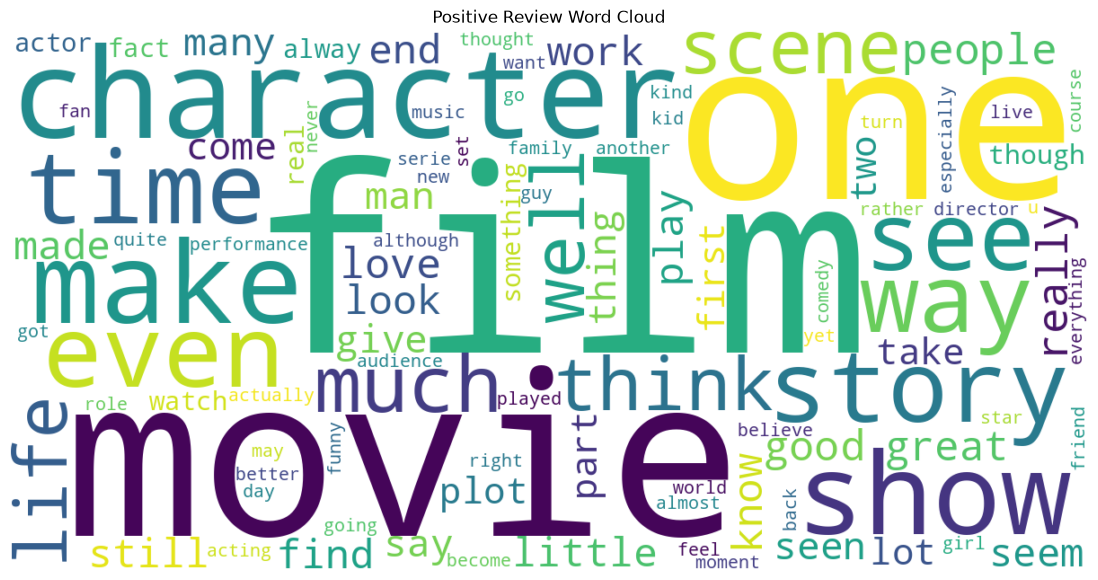

In [ ]:
    positive_text = " ".join(
        data.loc[data["sentiment"] == "positive", "review"]
        .apply(lambda text: " ".join(clean_text_for_eda(text)))
    )

positive_wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=100
).generate(positive_text)

plt.figure(figsize=(14, 7))

plt.imshow(
    positive_wordcloud,
    interpolation="bilinear"
)

plt.axis("off")
plt.title("Positive Review Word Cloud")

plt.show()

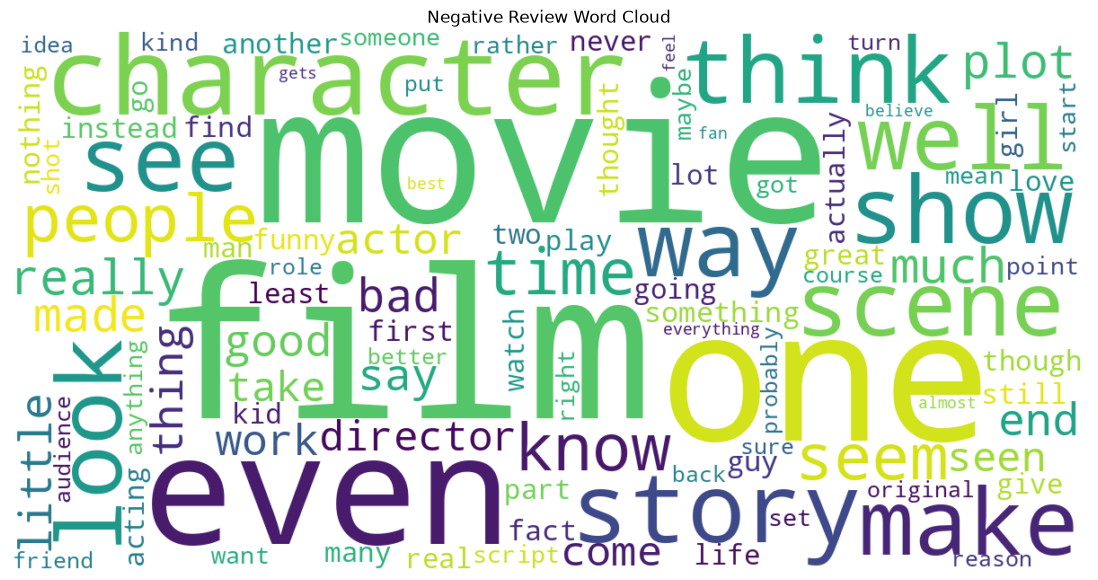

In [128]:
negative_text = " ".join(
    data.loc[data["sentiment"] == "negative", "review"]
    .apply(lambda text: " ".join(clean_text_for_eda(text)))
)

negative_wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=100
).generate(negative_text)

plt.figure(figsize=(14, 7))

plt.imshow(
    negative_wordcloud,
    interpolation="bilinear"
)

plt.axis("off")
plt.title("Negative Review Word Cloud")

plt.show()